In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sheryanalysis as sh
import warnings
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv("/home/ali-mirza/AI-ML/data/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [13]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [14]:
df.shape

(918, 12)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [16]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [17]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

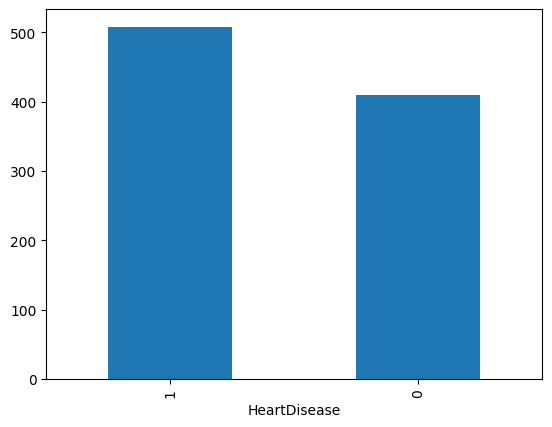

In [18]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [19]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

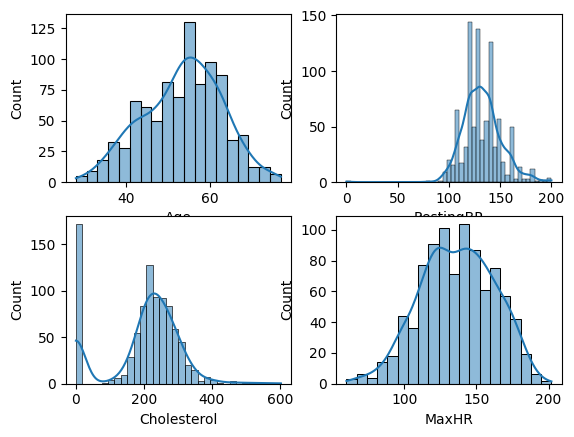

In [20]:
def plotting(var , num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var],kde=True)
    

plot_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
    
for index , col in enumerate(plot_col):
    plotting(col,index+1)  
    
plt.tight_layout

In [21]:
# Since a person can't have 0 Resting-BP and Cholesterol so we will fix it
cholesterol_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0, cholesterol_mean).round(2)

resting_bp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean).round(2)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

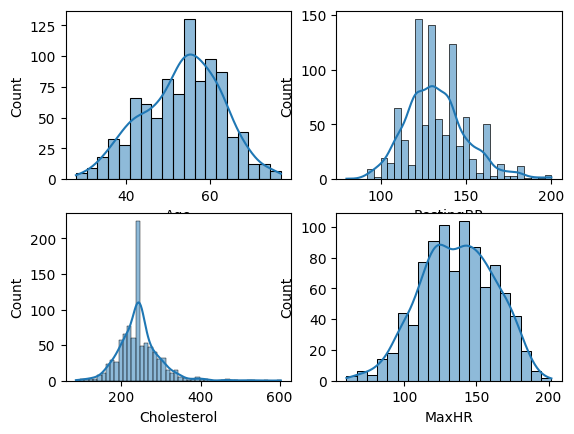

In [22]:
def plotting(var , num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var],kde=True)
    

plot_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
    
for index , col in enumerate(plot_col):
    plotting(col,index+1)  
    
plt.tight_layout

In [23]:
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(na_value=nan)>,
  'ChestPainType': <StringDtype(na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',

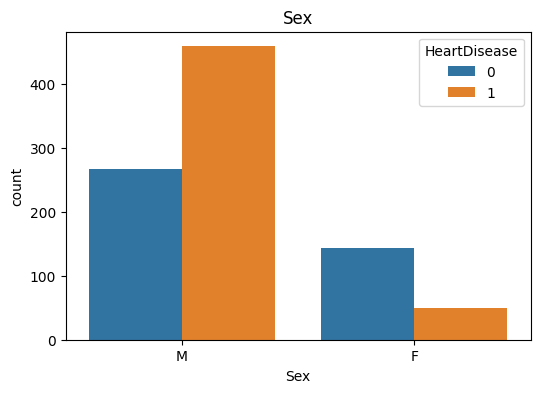

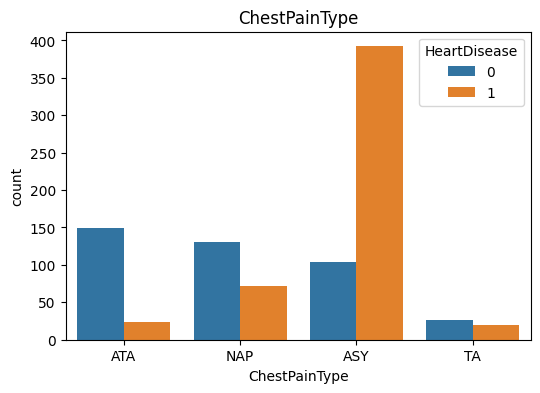

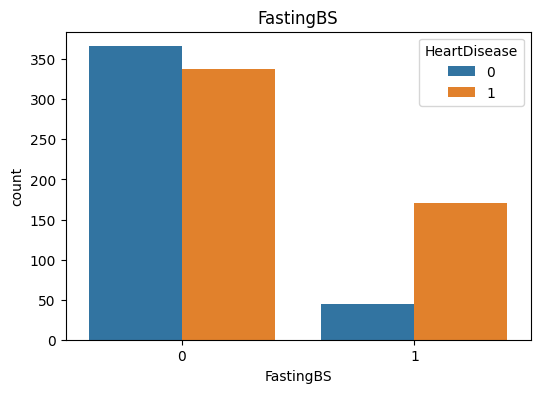

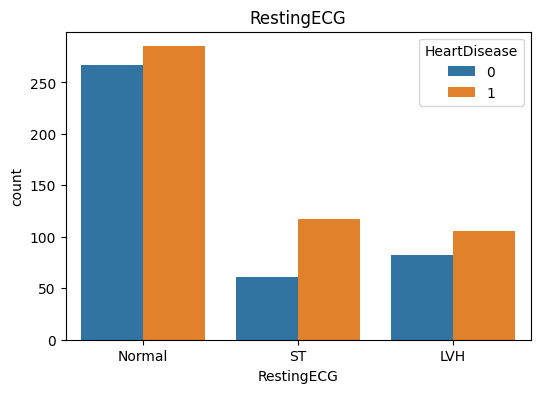

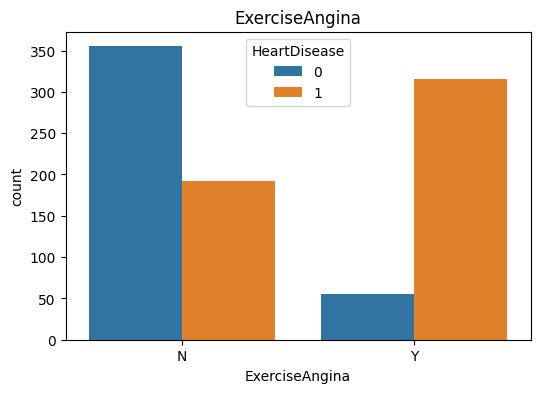

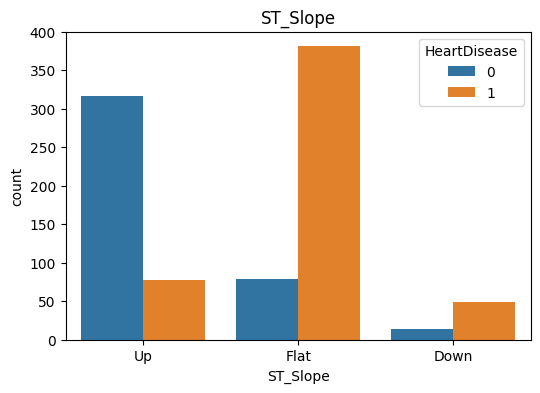

In [24]:
categorical_Columns = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_Columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df[col],hue=df['HeartDisease'])
    plt.title(col)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

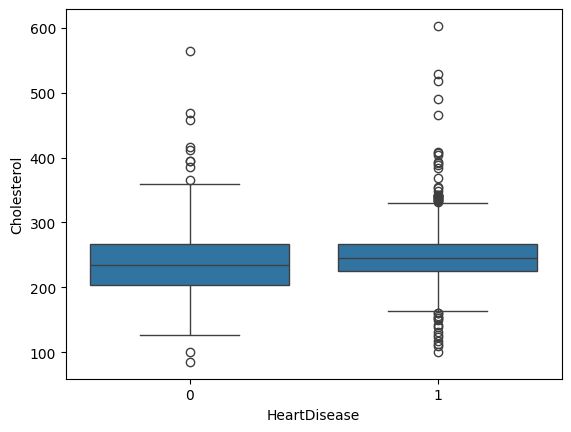

In [25]:
sns.boxplot(x = 'HeartDisease' ,y = 'Cholesterol' , data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

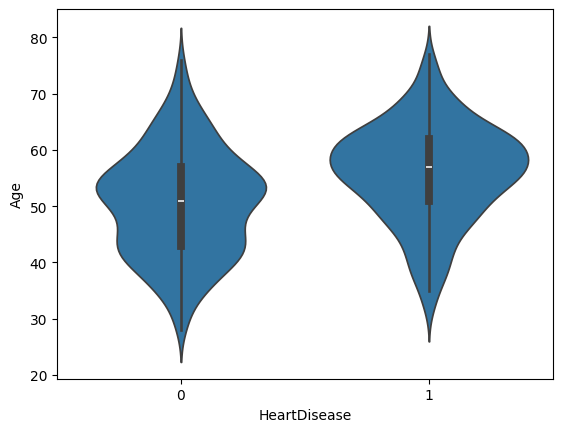

In [26]:
sns.violinplot(x = "HeartDisease" , y = "Age" , data=df)

<Axes: >

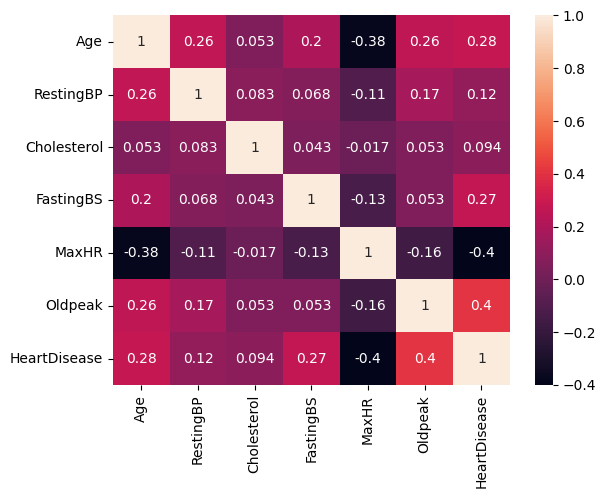

In [27]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Cleaning And Preprocessing

In [28]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [29]:
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [31]:
X = df_encode.drop('HeartDisease', axis=1)
Y = df_encode['HeartDisease']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)
X_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
585,57,180,285,1,120,0,1,1,0,0,0,1,0,1,0
169,58,140,179,0,160,0,1,0,1,0,1,0,0,0,1
602,61,120,337,0,98,0,1,0,1,0,1,0,1,1,0
140,52,160,331,0,94,2,1,0,0,0,1,0,1,1,0
173,49,140,187,0,172,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,48,120,254,0,110,0,0,0,0,0,0,1,0,0,1
270,45,120,225,0,140,0,1,0,0,0,1,0,0,0,1
860,60,130,253,0,144,1,1,0,0,0,1,0,1,0,1
435,60,152,244,0,118,0,1,0,0,0,0,1,1,0,1


In [33]:
# columns = ['Age' ,'RestingBP' ,'Cholesterol' ,'MaxHR']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
models = {
    "Logistic Regression" : LogisticRegression(C=0.1, max_iter=1000),
    "KNN" : KNeighborsClassifier(n_neighbors=9),
    "Naive Bayes" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM" : SVC(probability=True)
}

In [35]:
result = []

for name,model in models.items():
    model.fit(X_train_scaled , y_train)
    pred = model.predict(X_test_scaled) 
    acc = accuracy_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    result.append({
        "Model" : name,
        "Accuracy" : round(acc , 4),
        "F1 Score" : round(f1 , 4)
    })  
    
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.868, 'F1 Score': 0.8837},
 {'Model': 'KNN', 'Accuracy': 0.8746, 'F1 Score': 0.8902},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8515, 'F1 Score': 0.8673},
 {'Model': 'Decision Tree', 'Accuracy': 0.7327, 'F1 Score': 0.7508},
 {'Model': 'SVM', 'Accuracy': 0.8515, 'F1 Score': 0.8696}]

In [37]:
import joblib

joblib.dump(models['KNN'], 'PKL files/KNN_heart.pkl')
joblib.dump(scaler, 'PKL files/scaler.pkl')
joblib.dump(X.columns.tolist, 'PKL files/columns.pkl')


['PKL files/columns.pkl']